# Portfolio Optimization & Risk Analysis using Monte Carlo Simulation
## by Wojciech Obszański 

In [89]:
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import datetime
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans

### Import data:
We are taking portfolio which has S&P500, GOOGLE, NVIDIA, APPLE, MICROSOFT, KGHM, PALANTIR, ALIBABA, TOYOTA and SPOTIFY stocks.

In [90]:
tickers = ['^GSPC', 'AMD', 'NVDA', 'AAPL', 'MSFT', 'KGH.WA', 'PLTR']

today = datetime.date.today().strftime('%Y-%m-%d')
data = yf.download(tickers, start='2020-01-01', end=today)

data.head()

[*********************100%***********************]  7 of 7 completed


Price           Close                                                   \
Ticker           AAPL        AMD     KGH.WA        MSFT      NVDA PLTR   
Date                                                                     
2020-01-01        NaN        NaN  89.064735         NaN       NaN  NaN   
2020-01-02  72.271538  49.099998  91.226578  151.829529  5.963804  NaN   
2020-01-03  71.568901  48.599998  89.567909  149.938995  5.868347  NaN   
2020-01-06  72.139198  48.389999  89.567909  150.326553  5.892958  NaN   
2020-01-07  71.799927  48.250000  89.418816  148.955933  5.964301  NaN   

Price                         High                        ...      Open       \
Ticker            ^GSPC       AAPL        AMD     KGH.WA  ...      NVDA PLTR   
Date                                                      ...                  
2020-01-01          NaN        NaN        NaN  89.064735  ...       NaN  NaN   
2020-01-02  3257.850098  72.331694  49.250000  91.506124  ...  5.934968  NaN   
2020-01-03  3234.850098  72.326866  49.389999  90.387921  ...  5.844234  NaN   
2020-01-06  3246.280029  72.177699  48.860001  89.567909  ...  5.775129  NaN   
2020-01-07  3237.179932  72.403889  49.389999  90.574288  ...  5.921295  NaN   

Price                         Volume                                    \
Ticker            ^GSPC         AAPL         AMD    KGH.WA        MSFT   
Date                                                                     
2020-01-01          NaN          NaN         NaN       0.0         NaN   
2020-01-02  3244.669922  135480400.0  80331100.0  232235.0  22622100.0   
2020-01-03  3226.360107  146322800.0  73127400.0  317912.0  21116200.0   
2020-01-06  3217.550049  118387200.0  47934900.0       0.0  20813700.0   
2020-01-07  3241.860107  108872000.0  58061400.0  314584.0  21634100.0   

Price                                       
Ticker             NVDA PLTR         ^GSPC  
Date                                        
2020-01-01          NaN  NaN           NaN  
2020-01-02  237536000.0  NaN  3.459930e+09  
2020-01-03  205384000.0  NaN  3.484700e+09  
2020-01-06  262636000.0  NaN  3.702460e+09  
2020-01-07  314856000.0  NaN  3.435910e+09  

[5 rows x 35 columns]

In [91]:
data.describe()

Price         Close                                                      \
Ticker         AAPL          AMD       KGH.WA         MSFT         NVDA   
count   1663.000000  1663.000000  1664.000000  1663.000000  1663.000000   
mean     175.447422   134.216422   148.416771   323.993874    70.523278   
std       58.799892    91.340090    63.766944   100.774364    67.636077   
min       54.117031    38.709999    46.032616   128.358368     4.885130   
25%      135.720657    83.705002   111.732843   239.613312    15.396009   
50%      168.887756   108.300003   130.291252   314.781860    30.290588   
75%      219.047630   155.180000   164.783253   409.345825   128.158775   
max      339.786926   580.909973   390.318573   538.658569   235.465576   

Price                                    High                            ...  \
Ticker         PLTR        ^GSPC         AAPL          AMD       KGH.WA  ...   
count   1475.000000  1663.000000  1663.000000  1663.000000  1664.000000  ...   
mean      53.043736  4823.508701   177.249881   137.043903   150.909795  ...   
std       57.324588  1236.112230    59.248366    93.737747    65.006725  ...   
min        6.000000  2237.399902    55.113170    41.700001    49.182214  ...   
25%       14.090000  3950.664917   138.279401    85.535000   113.244591  ...   
50%       23.590000  4463.120117   170.410567   110.480003   132.404619  ...   
75%       84.840000  5768.885010   221.060774   157.814995   166.892700  ...   
max      207.179993  7798.990234   344.273097   584.729980   394.699694  ...   

Price          Open                                  Volume                \
Ticker         NVDA         PLTR        ^GSPC          AAPL           AMD   
count   1663.000000  1475.000000  1663.000000  1.663000e+03  1.663000e+03   
mean      70.535959    53.008839  4822.453717  8.139849e+07  5.881944e+07   
std       67.694119    57.343002  1235.659132  5.039610e+07  2.881678e+07   
min        4.977161     5.980000  2290.709961  1.791060e+07  7.956800e+06   
25%       15.365340    14.115000  3948.680054  4.866015e+07  3.836785e+07   
50%       30.347737    23.760000  4462.640137  6.692180e+07  5.144250e+07   
75%      128.118822    83.685001  5766.940186  9.643545e+07  7.244190e+07   
max      229.602402   205.044998  7806.600098  4.265100e+08  2.488596e+08   

Price                                                                         
Ticker        KGH.WA          MSFT          NVDA          PLTR         ^GSPC  
count   1.664000e+03  1.663000e+03  1.663000e+03  1.475000e+03  1.663000e+03  
mean    7.203607e+05  2.849734e+07  3.861488e+08  5.812376e+07  4.597352e+09  
std     4.001546e+05  1.342603e+07  1.993914e+08  4.003117e+07  1.096308e+09  
min     0.000000e+00  5.855900e+06  6.552850e+07  9.126400e+06  0.000000e+00  
25%     4.528895e+05  2.009655e+07  2.220180e+08  3.392475e+07  3.845765e+09  
50%     6.125785e+05  2.528110e+07  3.637090e+08  4.649950e+07  4.393220e+09  
75%     8.787680e+05  3.302960e+07  5.033740e+08  6.721805e+07  5.115880e+09  
max     3.788768e+06  1.862016e+08  1.543911e+09  4.502905e+08  1.002582e+10  

[8 rows x 35 columns]

## Data Cleaning
Dataset contains NaN values, which primarily occur when one stock exchange was closed for a holiday while another was open.
### My cleaning process is as follows:

1) For the Volume column: I will fill NaN values with 0. A closed market means zero trading volume.

2) For price columns (Open, High, Low, Close): I will forward-fill the NaN values. This propagates the last known price to the day the market was closed, correctly assuming the price did not change.

3) After filling, I will drop any remaining rows with NaNs. This handles cases at the very beginning of the dataset where historical data was not available for all assets.

In [92]:
data['Volume'] = data['Volume'].fillna(0) # first step

data = data.ffill() # second step

clean_df = data.dropna() # third step

clean_df.head(20) #checking the clean data

Price            Close                                                       \
Ticker            AAPL        AMD      KGH.WA        MSFT       NVDA   PLTR   
Date                                                                          
2020-09-30  112.235855  81.989998  109.956451  200.400574  13.472141   9.50   
2020-10-01  113.185616  84.860001  107.300720  202.430023  13.555779   9.46   
2020-10-02  109.531944  81.800003  107.160942  196.456024  13.005909   9.20   
2020-10-05  112.904564  86.150002  110.236000  200.448227  13.583655   9.03   
2020-10-06  109.667648  84.480003  109.210976  196.189240  13.677249   9.90   
2020-10-07  111.528381  86.690002  111.820114  199.924179  13.903769  10.00   
2020-10-08  111.421783  86.510002  108.232559  200.638794  13.779063  10.00   
2020-10-09  113.360054  83.099998  111.773529  205.621841  13.703388   9.95   
2020-10-12  120.560715  84.290001  113.590599  210.947922  14.164638   9.89   
2020-10-13  117.362587  85.279999  110.888275  212.339050  14.186792   9.47   
2020-10-14  117.449806  84.209999  116.013374  210.433441  14.034455   9.34   
2020-10-15  116.984619  83.129997  116.013374  209.290131  13.909744   9.91   
2020-10-16  115.346764  83.169998  117.737274  209.290131  13.751925   9.71   
2020-10-19  112.400604  82.000000  116.479294  204.106964  13.439530   9.57   
2020-10-20  113.883385  81.559998  119.461159  204.516617  13.586643   9.27   
2020-10-21  113.263161  79.199997  122.256676  204.659561  13.466414   9.20   
2020-10-22  112.177711  79.419998  118.436142  204.745316  13.303370   9.68   
2020-10-23  111.489616  81.959999  117.877037  206.022034  13.531631   9.49   
2020-10-26  111.499283  82.230003  116.479294  200.162354  13.084566   9.95   
2020-10-27  113.001480  78.879997  117.271339  203.182709  13.338968  10.95   

Price                          High                         ...       Open  \
Ticker            ^GSPC        AAPL        AMD      KGH.WA  ...       NVDA   
Date                                                        ...              
2020-09-30  3363.000000  113.641109  82.940002  110.329187  ...  13.100750   
2020-10-01  3380.800049  114.086914  85.250000  111.959892  ...  13.698661   
2020-10-02  3348.419922  111.809424  84.650002  107.440495  ...  13.167957   
2020-10-05  3408.600098  113.049936  86.279999  111.167834  ...  13.178909   
2020-10-06  3360.969971  112.536296  87.250000  111.167833  ...  13.770346   
2020-10-07  3419.439941  111.983877  87.790001  111.820114  ...  13.939366   
2020-10-08  3446.830078  112.807651  88.720001  113.124689  ...  14.014294   
2020-10-09  3477.139893  113.389127  85.750000  111.773529  ...  13.707620   
2020-10-12  3534.219971  121.316641  85.129997  116.665648  ...  13.929158   
2020-10-13  3511.929932  121.520189  86.089996  113.683778  ...  14.234834   
2020-10-14  3488.669922  119.233016  85.959999  116.852027  ...  14.228863   
2020-10-15  3483.340088  117.459495  84.720001  116.619068  ...  13.751181   
2020-10-16  3483.810059  117.798688  83.989998  119.880489  ...  13.976204   
2020-10-19  3426.919922  116.703571  84.650002  119.694119  ...  13.843032   
2020-10-20  3443.120117  115.308018  82.690002  119.461159  ...  13.524910   
2020-10-21  3435.560059  115.046371  81.930000  122.303270  ...  13.566232   
2020-10-22  3453.489990  114.397038  80.820000  122.629404  ...  13.464174   
2020-10-23  3465.389893  112.953017  81.989998  119.787300  ...  13.391986   
2020-10-26  3400.969971  112.952989  84.970001  118.110004  ...  13.369084   
2020-10-27  3390.679932  113.660494  82.370003  118.902049  ...  13.248609   

Price                                Volume                          \
Ticker       PLTR        ^GSPC         AAPL          AMD     KGH.WA   
Date                                                                  
2020-09-30  10.00  3341.209961  142675200.0   51533700.0   572246.0   
2020-10-01   9.69  3385.870117  116120400.0   52177100.0   370488.0   
2020-10-02   9.06  3338.939941  

### Currency fix
KGHM (`KGH.WA`) is traded in PLN, while every other ticker in this portfolio (including `^GSPC`) is in USD. Before computing returns, correlations, and weights, we convert KGHM prices to USD using the USDPLN exchange rate, so the whole portfolio is expressed in one common currency.

In [93]:
fx = yf.download('USDPLN=X', start='2020-01-01', end='2025-11-01')['Close']
fx = fx.reindex(clean_df.index).ffill().bfill()
fx_rate = fx.iloc[:, 0] if hasattr(fx, 'iloc') and fx.ndim == 2 else fx

for price_col in ['Open', 'High', 'Low', 'Close']:
    clean_df[(price_col, 'KGH.WA')] = clean_df[(price_col, 'KGH.WA')] / fx_rate

clean_df['Close'][['KGH.WA']].head()

[*********************100%***********************]  1 of 1 completed


Ticker,KGH.WA
Date,
2020-09-30,28.529735
2020-10-01,27.785158
2020-10-02,28.098206
2020-10-05,28.768725
2020-10-06,28.662040


###  Visualisation of some important data:

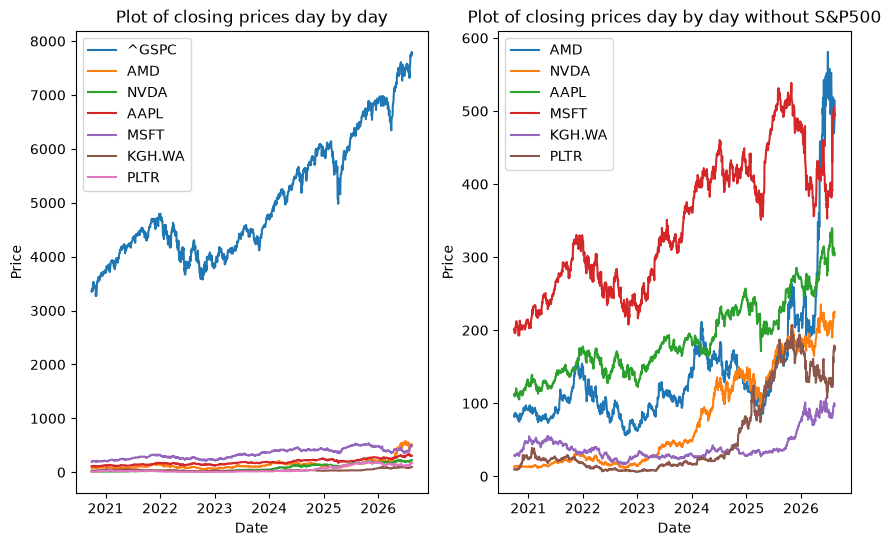

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
close_df = clean_df['Close']

for ticker in tickers:
    ax[0].plot(close_df[ticker], label=ticker)
    ax[0].set_xlabel('Date')
    ax[0].set_ylabel('Price')
    ax[0].set_title('Plot of closing prices day by day')
ax[0].legend(loc='upper left')
    
tickers2 = ['AMD', 'NVDA', 'AAPL', 'MSFT', 'KGH.WA', 'PLTR']
for ticker in tickers2:
    ax[1].plot(close_df[ticker], label=ticker)
    ax[1].set_xlabel('Date')
    ax[1].set_ylabel('Price')
    ax[1].set_title('Plot of closing prices day by day without S&P500')
ax[1].legend(loc='upper left')

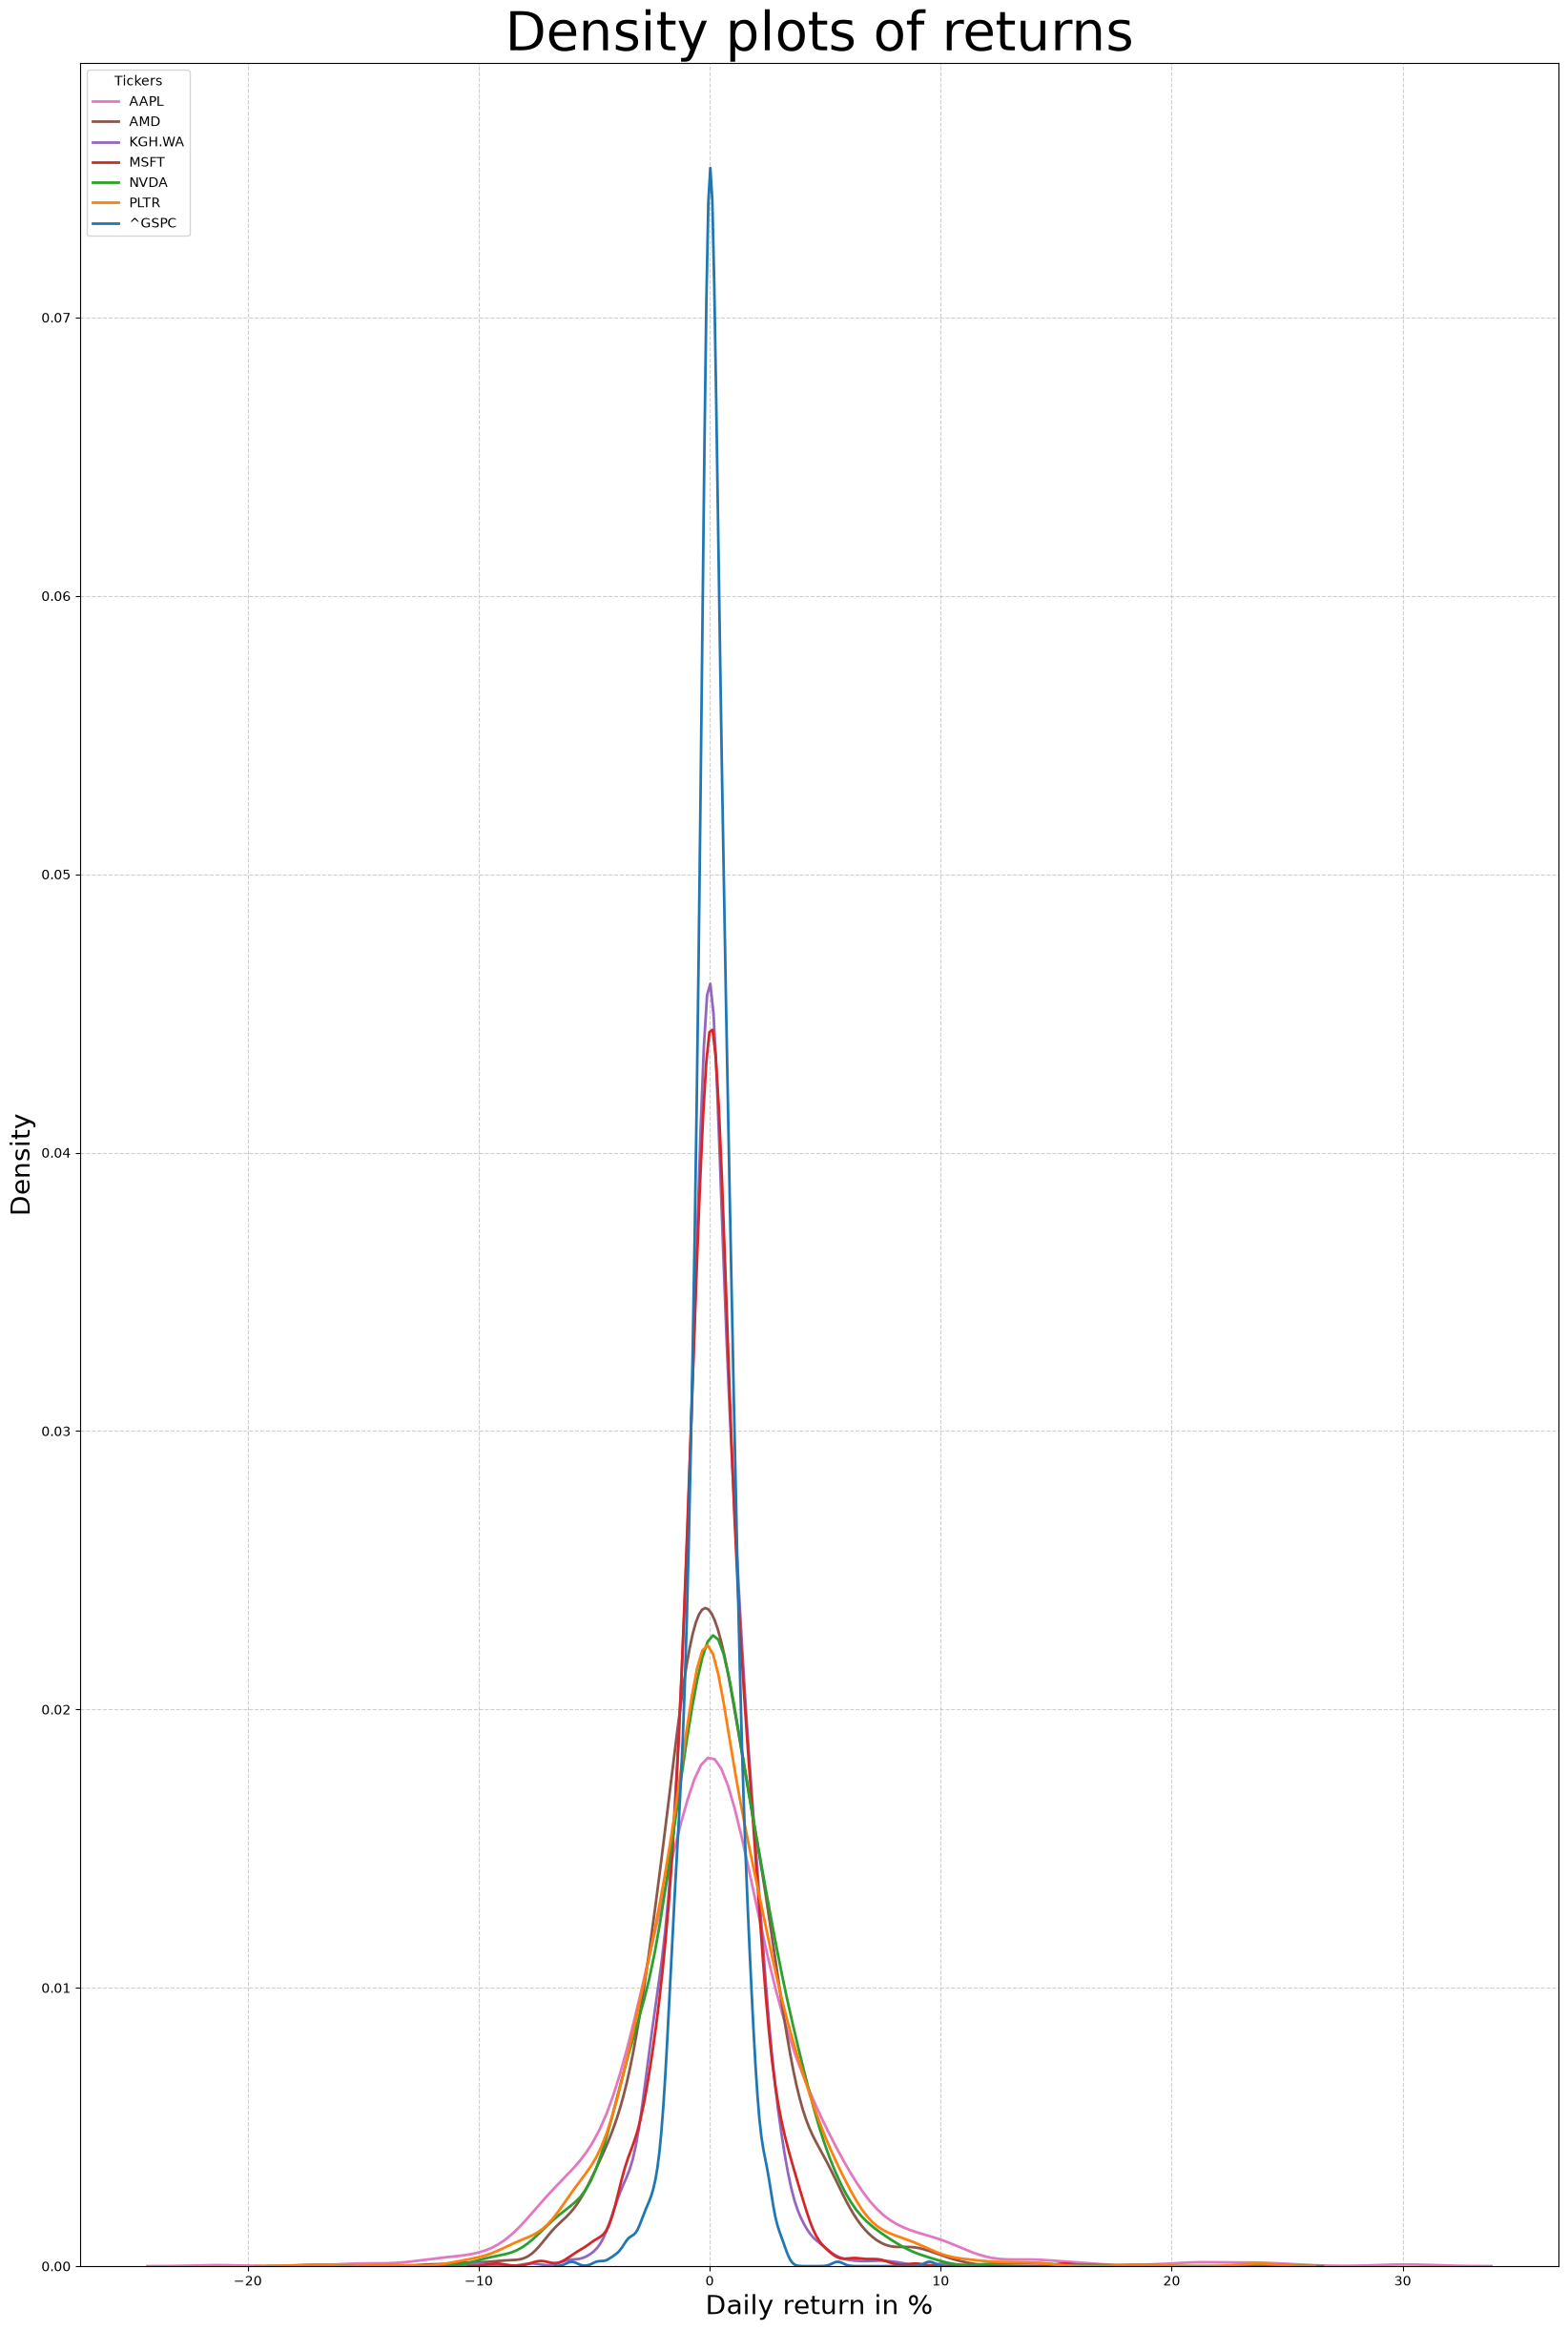

In [95]:
plt.figure(figsize = (20,30))
sns.kdeplot(data= (close_df[tickers].pct_change() * 100).dropna(), linewidth= 2.0)
plt.title('Density plots of returns', fontsize=40)
plt.xlabel('Daily return in %', fontsize=20)
plt.ylabel('Density', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(labels= data['Close'].columns, title= 'Tickers', loc='upper left')

plt.show()




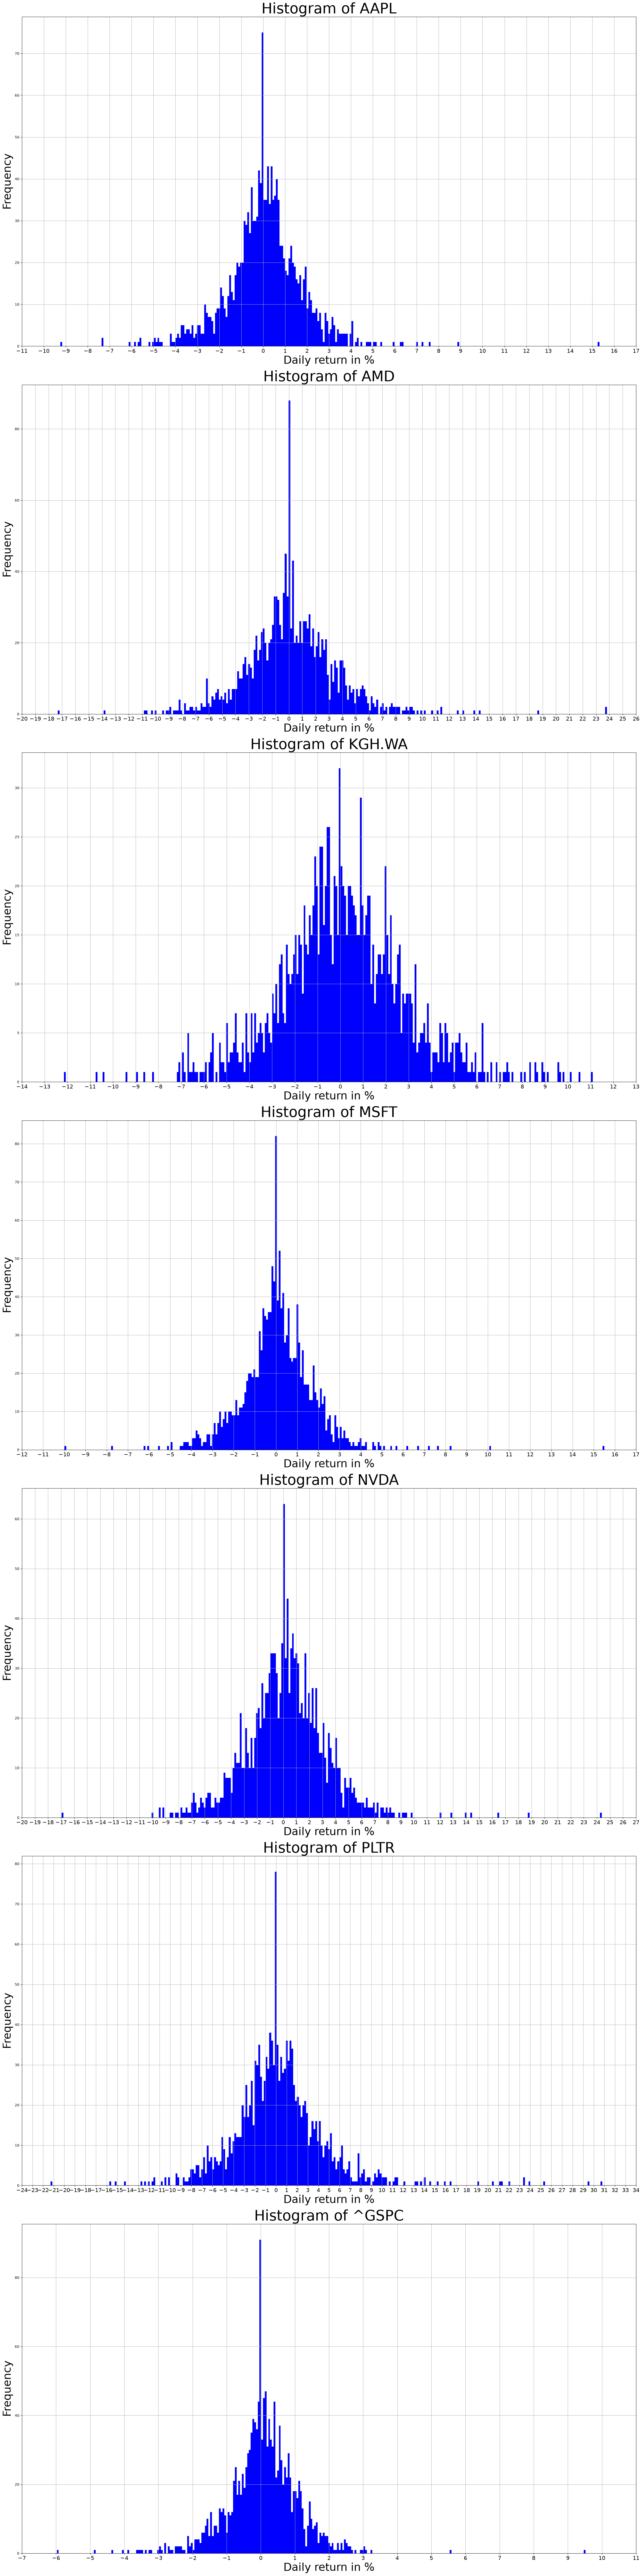

In [96]:
axes = (close_df.pct_change() * 100).dropna().hist(bins=300, color='blue', layout=(len(close_df.columns), 1), figsize=(25, 100))

for ax in axes.flatten():
    title = ax.get_title()
    ax.set_title(f'Histogram of {title}', fontsize=40)
    ax.set_ylabel('Frequency', fontsize=30)
    ax.set_xlabel('Daily return in %', fontsize=30)
    ax.tick_params(axis='x', labelsize=15)
    x_min, x_max = ax.get_xlim()
    ax.set_xticks(np.arange(np.floor(x_min), np.ceil(x_max) + 1, 1))

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Daily correlation matrix')

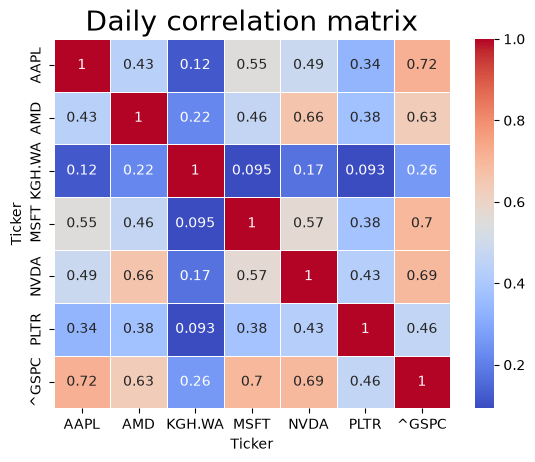

In [97]:
daily_returns = close_df.pct_change().dropna()
corr_matrix = daily_returns.corr() # Pearson correlation

sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', linewidths= 0.5)
plt.title('Daily correlation matrix', fontsize=20)


## Portfolio Modeling

In [98]:
daily_returns = close_df.pct_change().dropna()

avg_return = daily_returns.mean() # average of daily returns
cov_matrix = daily_returns.cov() # covariant matrix

num_assets = daily_returns.shape[1] #write a number of our assets down


 We have to define a sample weights

In [99]:
weights = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,]) # let's give each of our assets the same weight

Now, we have to calculate expected annual return.


We will use formula:  Portfolio return = (weight A * avg_return A) + (weight B * avg_return B) + ...

In [100]:
annual_expected_return = np.dot(weights, avg_return) * 252 # np.dot(weights, avg_return) means daily expected return, so we have to multiply by 252, because we have around 252 stock exchange open' s days

print(f"Expected Annual Return: {annual_expected_return * 100:.2f}% .")

Expected Annual Return: 26.06% .


Now, We're going to calculate Annual Portfolio Risk

We're using formula: Variability = √ (weights^T * cov_matrix * weights)

In [101]:
annual_expected_risk = np.sqrt(np.dot(np.dot(weights.T, cov_matrix), weights) * 252) # np.dot(np.dot(weights.T, cov_matrix), weights) means daily expected risk, so we have to multiply by 252, because we have around 252 stock exchange open' s days. We put everything under √, because √(np.dot(np.dot(weights.T, cov_matrix), weights)) * √252 = √(np.dot(np.dot(weights.T, cov_matrix), weights) * 252)

print(f'Expected Anually Risk: {annual_expected_risk * 100:.2f}%.')

Expected Anually Risk: 20.07%.


Now, we're going to calculate Shape Ratio


We're using formula: Sharpe ratio = (Annualy return - Risk Free Rate) / Annualy Risk


For simplicity, We assume that Risk Free Rate is equal 0.

In [102]:
risk_free_rate = 0.0

sharpe_ratio = (annual_expected_return - risk_free_rate) / annual_expected_risk

print(f'Shape Ratio: {sharpe_ratio:.2f}.')

Shape Ratio: 1.30.


We can see that Sharpe Ratio is very low, which means that our portfolio is unfortunate.


### Let's start doing our Monte Carlo simulation

In [103]:
monte_carlo_results = []

risk_free_rate = 0.0
for _ in range(10000):
    weights = np.random.rand(7)
    weights /= weights.sum()
    
    annual_expected_return = np.dot(weights, avg_return) * 252
    annual_expected_risk = np.sqrt(np.dot(np.dot(weights.T, cov_matrix), weights) * 252)
    sharpe_ratio = (annual_expected_return - risk_free_rate) / annual_expected_risk

    monte_carlo_results.append({
        'weights': weights,
        'Annual Expected Return': annual_expected_return,
        'Expected Annual Risk': annual_expected_risk,
        'Expected Sharpe Ratio': sharpe_ratio,
    })


results_df = pd.DataFrame(monte_carlo_results)
results_df.head()

,weights,Annual Expected Return,Expected Annual Risk,Expected Sharpe Ratio
0,"[0.15236980092265467, 0.16397648490713407, 0.1...",0.400271,0.310040,1.291031
1,"[0.11046862475743197, 0.0744894164774899, 0.16...",0.405917,0.302941,1.339920
2,"[0.20050716447569827, 0.2794016655471424, 0.00...",0.311510,0.284453,1.095117
3,"[0.18027744676512716, 0.18925593644675703, 0.0...",0.429214,0.333295,1.287788
4,"[0.09929847310299432, 0.0996142876191015, 0.26...",0.363617,0.280089,1.298219


### Now we are looking for the best portfolio

We're searching for a portfolio with highest Sharpe Ratio

This will be the most optimal portfolio

In [104]:
max_sharpe_portfolio = results_df.loc[results_df['Expected Sharpe Ratio'].idxmax()]

tickers_with_weights = []
for i in range(7):
    tickers_with_weights.append((tickers[i], max_sharpe_portfolio['weights'][i]))

print("Maximal Sharpe Portfolio:")
print(f"Annual Return: {max_sharpe_portfolio['Annual Expected Return'] * 100:.2f}%")
print(f"Annual Risk: {max_sharpe_portfolio['Expected Annual Risk'] * 100:.2f}%")
print(f"Sharpe Ratio: {max_sharpe_portfolio['Expected Sharpe Ratio']:.2f}")
print(f"Assets with weights: {tickers_with_weights}")

Maximal Sharpe Portfolio:
Annual Return: 48.88%
Annual Risk: 35.08%
Sharpe Ratio: 1.39
Assets with weights: [('^GSPC', np.float64(0.06999444095609553)), ('AMD', np.float64(0.021470499267878463)), ('NVDA', np.float64(0.32023819942134146)), ('AAPL', np.float64(0.019781326881124096)), ('MSFT', np.float64(0.32312364772342367)), ('KGH.WA', np.float64(0.2406307819415642)), ('PLTR', np.float64(0.004761103808572545))]


We're searching for a portfolio with lowest Risk

This will be the safest portfolio

In [105]:
min_risk_portfolio = results_df.loc[results_df['Expected Annual Risk'].idxmin()]

tickers_with_weights = []
for i in range(7):
    tickers_with_weights.append((tickers[i], min_risk_portfolio['weights'][i]))

print("Minimal Risk Portfolio:")
print(f"Annual Return: {min_risk_portfolio['Annual Expected Return'] * 100:.2f}%")
print(f"Annual Risk: {min_risk_portfolio['Expected Annual Risk'] * 100:.2f}%")
print(f"Sharpe Ratio: {min_risk_portfolio['Expected Sharpe Ratio']:.2f}")
print(f"Assets with weights: {tickers_with_weights}")

Minimal Risk Portfolio:
Annual Return: 22.76%
Annual Risk: 19.96%
Sharpe Ratio: 1.14
Assets with weights: [('^GSPC', np.float64(0.11355701425616183)), ('AMD', np.float64(0.008209310049006232)), ('NVDA', np.float64(0.07905918042313742)), ('AAPL', np.float64(0.21524726750490042)), ('MSFT', np.float64(0.003803200955142804)), ('KGH.WA', np.float64(0.08046383522670693)), ('PLTR', np.float64(0.49966019158494446))]


### Efficient frontier
Let's visualize all 10,000 simulated portfolios at once: risk on the x-axis, return on the y-axis, colored by Sharpe Ratio. The max-Sharpe and min-risk portfolios found above are highlighted.

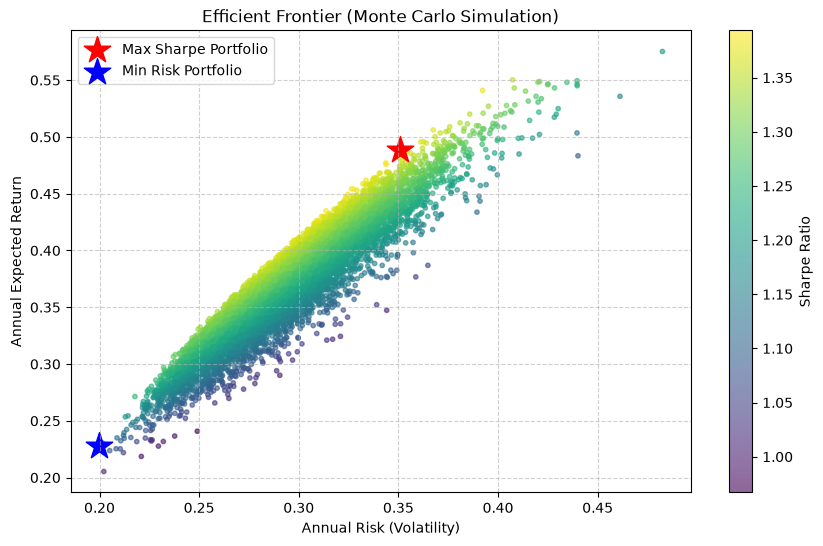

In [106]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    results_df['Expected Annual Risk'],
    results_df['Annual Expected Return'],
    c=results_df['Expected Sharpe Ratio'],
    cmap='viridis',
    alpha=0.6,
    s=10,

)
plt.colorbar(sc, label='Sharpe Ratio')

plt.scatter(
    max_sharpe_portfolio['Expected Annual Risk'],
    max_sharpe_portfolio['Annual Expected Return'],
    color='red', marker='*', s=400, label='Max Sharpe Portfolio'
)
plt.scatter(
    min_risk_portfolio['Expected Annual Risk'],
    min_risk_portfolio['Annual Expected Return'],
    color='blue', marker='*', s=400, label='Min Risk Portfolio'
)

plt.title('Efficient Frontier (Monte Carlo Simulation)')
plt.xlabel('Annual Risk (Volatility)')
plt.ylabel('Annual Expected Return')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Now we're going to discover how risky is one of the S&P500 companies in comparison to whole S&P500

We will need two indicators:
    1) Beta, which is measure of systematic risk
        - If Beta = 1 => The asset moves exactly in line with the market
        - If Beta > 1 => The asset is "aggressive". For example, a Beta of 1.5 suggests the asset may return 1.5% for every 1% return in the market.
        - If Beta < 1 => The asset is "defensive" (less volatile). A Beta of 0.8 suggests the asset may return 0.8% for every 1% market return
    2) Alpha represents the "edge" or "quality" of the investment. It tells us how much an asset returned above or below what was expected, given its level of risk
    
### CAPM Model: 


y = mx + c


y -> The Company  returns


x -> S&P500 returns


m -> Our Beta


c -> Our Alpha



### CAPM MODEL for NVDA

 CAPM results for NVIDIA and S&P 500:
Beta: 2.1014
Alpha: 0.0011


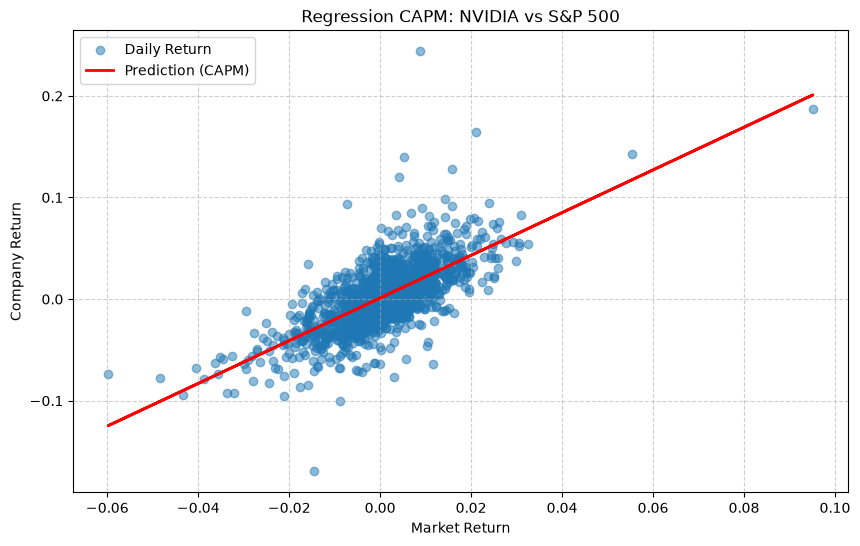

In [107]:
model1 = LinearRegression()
model1.fit(daily_returns[['^GSPC']], daily_returns['NVDA'])

beta = model1.coef_[0] # coef is a lean (m) which is beta
alpha = model1.intercept_ # intercept is our constant term which is alpha

print(" CAPM results for NVIDIA and S&P 500:")
print(f"Beta: {beta:.4f}")
print(f"Alpha: {alpha:.4f}")

plt.figure(figsize = (10,6))
plt.scatter(daily_returns[['^GSPC']], daily_returns['NVDA'], alpha= 0.5, label= 'Daily Return') # market dependence
plt.plot(daily_returns[['^GSPC']], model1.predict(daily_returns[['^GSPC']]), color='red',linewidth=2, label= 'Prediction (CAPM)')
plt.title('Regression CAPM: NVIDIA vs S&P 500')
plt.xlabel('Market Return')
plt.ylabel('Company Return')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


We can see that NVIDIA is an example of high-Beta company, that means: When market is decreasing, Nvidia is decreasing rapidly, but when market is increasing, the company increasing rapidly

### CAPM MODEL  for PLTR

 CAPM results for Palantir and S&P 500:
Beta: 1.9649
Alpha: 0.0017


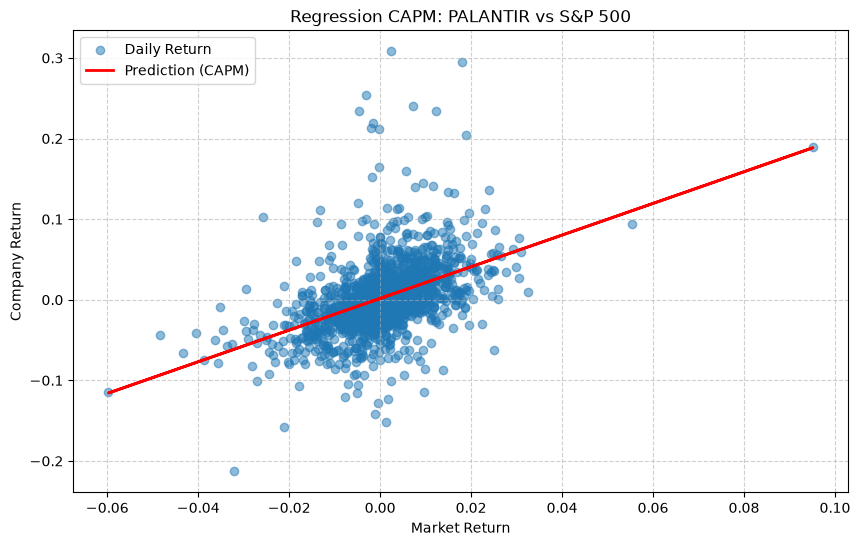

In [108]:
model2 = LinearRegression()
model2.fit(daily_returns[['^GSPC']], daily_returns['PLTR'])

beta = model2.coef_[0] # coef is a lean (m) which is beta
alpha = model2.intercept_ # intercept is our constant term which is alpha

print(" CAPM results for Palantir and S&P 500:")
print(f"Beta: {beta:.4f}")
print(f"Alpha: {alpha:.4f}")

plt.figure(figsize = (10,6))
plt.scatter(daily_returns[['^GSPC']], daily_returns['PLTR'], alpha= 0.5, label= 'Daily Return') # market dependence
plt.plot(daily_returns[['^GSPC']], model2.predict(daily_returns[['^GSPC']]), color='red',linewidth=2, label= 'Prediction (CAPM)')
plt.title('Regression CAPM: PALANTIR vs S&P 500')
plt.xlabel('Market Return')
plt.ylabel('Company Return')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Checking which company is more risky

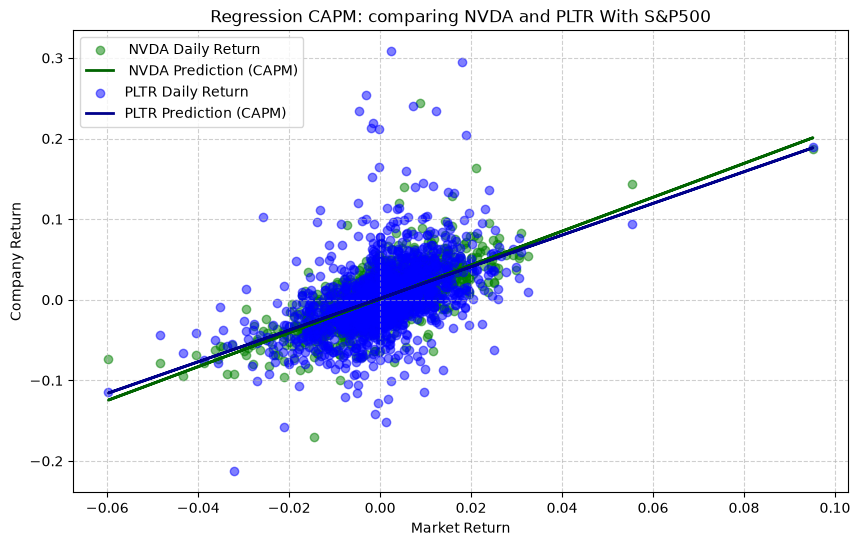

In [109]:
plt.figure(figsize = (10,6))
plt.scatter(daily_returns[['^GSPC']], daily_returns['NVDA'], alpha= 0.5, label= ' NVDA Daily Return', color='green') # market dependence
plt.plot(daily_returns[['^GSPC']], model1.predict(daily_returns[['^GSPC']]), color='darkgreen',linewidth=2, label= ' NVDA Prediction (CAPM)')
plt.xlabel('Market Return')
plt.ylabel('Company Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.scatter(daily_returns[['^GSPC']], daily_returns['PLTR'], alpha= 0.5, label= 'PLTR Daily Return', color='blue') # market dependence
plt.plot(daily_returns[['^GSPC']], model2.predict(daily_returns[['^GSPC']]), color='darkblue',linewidth=2, label= 'PLTR Prediction (CAPM)')
plt.title('Regression CAPM: comparing NVDA and PLTR With S&P500')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

We cen see that NVIDIA is more risky then PALANTIR in our portfolio

### Let's group companies in our portfolio
We will have three groups: 
    *) Very risky (Companies which are increasing rapidly)
    *) Very safe (Companies which are having vary slow, but almost constant rise ) 
    *) Stable (Companies which are growing quite fast but are less likely to decrease like 'Very risky' Company)

We will use K-Means clustering

In [110]:
# We need to prepare beta and alpha for each of companies

beta_results = {}
alpha_results = {}
for company in tickers:
    model = LinearRegression()
    model.fit(daily_returns[['^GSPC']], daily_returns[company])

    beta = model.coef_[0] 
    alpha = model.intercept_
    beta_results[company] = beta
    alpha_results[company] = alpha

In [111]:
daily_returns.head()
new_df = pd.DataFrame()
new_df['returns'] = daily_returns.mean() * 252 
new_df['risk'] = daily_returns.std() * np.sqrt(252)
new_df['beta'] = pd.Series(beta_results)
new_df['alpha'] = pd.Series(alpha_results)
new_df['sharpe'] = new_df['returns'] / new_df['risk']
new_df.head()

,returns,risk,beta,alpha,sharpe
Ticker,,,,,
AAPL,0.205236,0.277669,1.213464,0.000077,0.739141
AMD,0.450275,0.541031,2.087099,0.000519,0.832254
KGH.WA,0.301361,0.445918,0.705359,0.000767,0.675822
MSFT,0.186781,0.269862,1.147470,0.000044,0.692138
NVDA,0.590998,0.496744,2.101371,0.001069,1.189743


Now, we need to scaled our data, because there are huge difference in values between for example alpha and beta

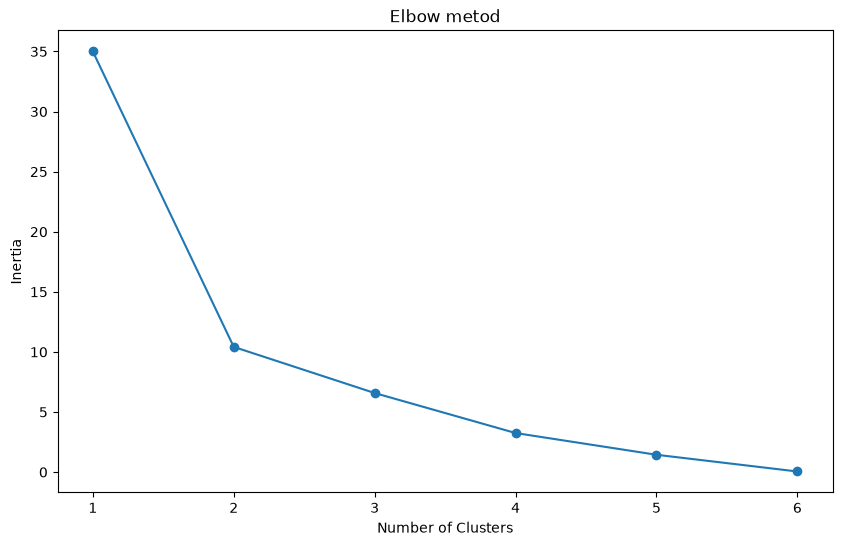

In [112]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(new_df)
X_scaled_df = pd.DataFrame(X_scaled, columns = new_df.columns, index = new_df.index)

inertia = []
for k in range(1,7):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    

plt.figure(figsize=(10,6))
plt.plot(range(1,7), inertia, marker = 'o')
plt.title('Elbow metod')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Now, lets make an appropriate clustering.
We're taking 2 clusters: Low risk, High risk


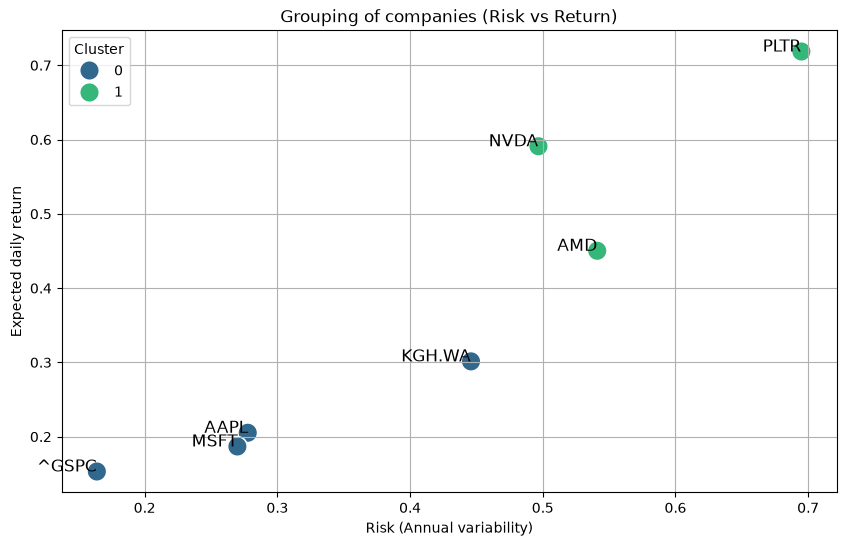

         returns      risk      beta         alpha    sharpe  Cluster
Ticker                                                               
AAPL    0.205236  0.277669  1.213464  7.723294e-05  0.739141        0
KGH.WA  0.301361  0.445918  0.705359  7.673611e-04  0.675822        0
MSFT    0.186781  0.269862  1.147470  4.409151e-05  0.692138        0
^GSPC   0.153094  0.163958  1.000000 -2.168404e-19  0.933738        0
AMD     0.450275  0.541031  2.087099  5.188642e-04  0.832254        1
NVDA    0.590998  0.496744  2.101371  1.068618e-03  1.189743        1
PLTR    0.718566  0.694894  1.964854  1.657777e-03  1.034067        1


In [113]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

new_df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=new_df, x='risk', y='returns', hue='Cluster', palette='viridis', s=200)

for idx, row in new_df.iterrows():
    plt.text(row['risk'], row['returns'], idx, 
             fontsize=12, ha='right')

plt.title('Grouping of companies (Risk vs Return)')
plt.xlabel('Risk (Annual variability)')
plt.ylabel('Expected daily return')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print(new_df.sort_values(by='Cluster'))

## Summary & Limitations

**Key findings:**
- The equal-weighted portfolio had a Sharpe Ratio of ~1.2, while the Monte Carlo search found portfolios with meaningfully higher risk-adjusted return (max Sharpe) and lower volatility (min risk) by re-weighting the same 10 assets.
- NVDA and PLTR both showed high Beta (>1.9) relative to the S&P 500, meaning they amplify market moves in both directions.
- K-Means clustering split the portfolio into a low-risk/low-return group and a high-risk/high-return group based on scaled return, risk, beta, and alpha.

**Limitations of this analysis:**
- The risk-free rate was assumed to be 0%, which is a simplification (it lowers the calculated Sharpe Ratio ceiling and is not realistic for the 2020-2025 period).
- No transaction costs, taxes, or rebalancing costs were modeled.
- All results are in-sample: the "optimal" portfolios were found and evaluated on the same historical window, with no out-of-sample or walk-forward validation.
- Historical returns/covariance are not guaranteed to hold in the future — this is a backward-looking risk/return analysis, not a forecast.

**Possible next steps:**
- Add an out-of-sample backtest (e.g. train on 2020-2023, test on 2024-2025).
- Replace the brute-force Monte Carlo search with a proper convex optimizer to trace the true efficient frontier.
- Use a realistic risk-free rate (e.g. 3-month T-bill yield) instead of 0%.

In [115]:
def split_train_test(daily_returns: pd.DataFrame, split_date: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_daily_returns = daily_returns.loc[:split_date]
    test_daily_returns = daily_returns.loc[split_date:]
    return train_daily_returns, test_daily_returns

train, test = split_train_test(daily_returns, "2024-12-31")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train zakres dat:", train.index.min(), "-", train.index.max())
print("Test zakres dat:", test.index.min(), "-", test.index.max())

Train shape: (1098, 7)
Test shape: (418, 7)
Train zakres dat: 2020-10-01 00:00:00 - 2024-12-31 00:00:00
Test zakres dat: 2024-12-31 00:00:00 - 2026-08-14 00:00:00
